# 05 — Linear systems

Direct (LU) versus iterative (Jacobi, Gauss-Seidel, conjugate gradient) solves.
Iterative methods shine on large, sparse, or structured problems; direct
methods are cheaper for small dense systems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import (
    lu_decomposition, lu_solve, gauss_elimination,
    jacobi, gauss_seidel, conjugate_gradient,
)


## A 5x5 random system, three different solvers

In [2]:
rng = np.random.default_rng(0)
n = 5
A = rng.standard_normal((n, n)) + n*np.eye(n)
b = rng.standard_normal(n)

x_lu  = gauss_elimination(A, b)
x_np  = np.linalg.solve(A, b)
print('||x_LU - x_np|| =', np.linalg.norm(x_lu - x_np))

L, U, P = lu_decomposition(A)
print('||PA - LU||     =', np.linalg.norm(P @ A - L @ U))


||x_LU - x_np|| = 5.887846720064156e-17
||PA - LU||     = 0.0


## Iterative solvers on an SPD diagonally-dominant system

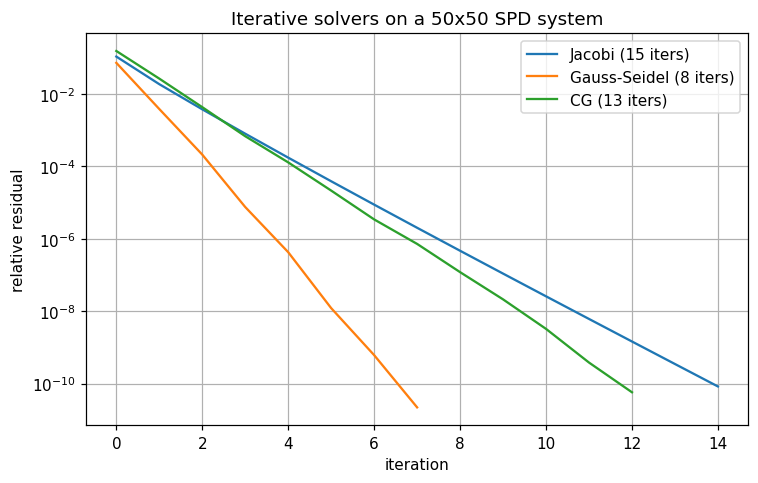

In [ ]:
# Build A = M M^T + cI, then add an extra ridge so Jacobi/GS converge.
rng = np.random.default_rng(0)
n = 50
M = rng.standard_normal((n, n))
A_spd = M @ M.T + n*np.eye(n)
# Boost the diagonal so the matrix is strictly diagonally dominant -
# Jacobi requires this; CG only needs SPD.
A_spd += np.diag(np.abs(A_spd).sum(axis=1))
b = rng.standard_normal(n)

j  = jacobi(A_spd, b, tol=1e-10, max_iter=2000)
gs = gauss_seidel(A_spd, b, tol=1e-10, max_iter=2000)
cg = conjugate_gradient(A_spd, b, tol=1e-10)

fig, ax = plt.subplots()
ax.semilogy(j.history,  label=f'Jacobi ({j.iterations} iters)')
ax.semilogy(gs.history, label=f'Gauss-Seidel ({gs.iterations} iters)')
ax.semilogy(cg.history, label=f'CG ({cg.iterations} iters)')
ax.set_xlabel('iteration'); ax.set_ylabel('relative residual')
ax.set_title('Iterative solvers on a 50x50 SPD system'); ax.legend()
fig.tight_layout(); plt.show()


CG is the clear winner on SPD problems—it provably terminates in at most $n$ steps in exact arithmetic. This notebook demonstrates `numethods.linsys`.